# Nested Spaces Visualization

Each child space applies the **same** TRS transform on top of its parent:
- Translate: (1, 0)
- Rotate: π/4 (45°)
- Scale: 1/√2 ≈ 0.707

Because the scale exactly cancels the rotation's diagonal, successive spaces
form a graceful spiral. We draw a small triangle in each local space,
then convert everything to absolute coordinates for plotting.


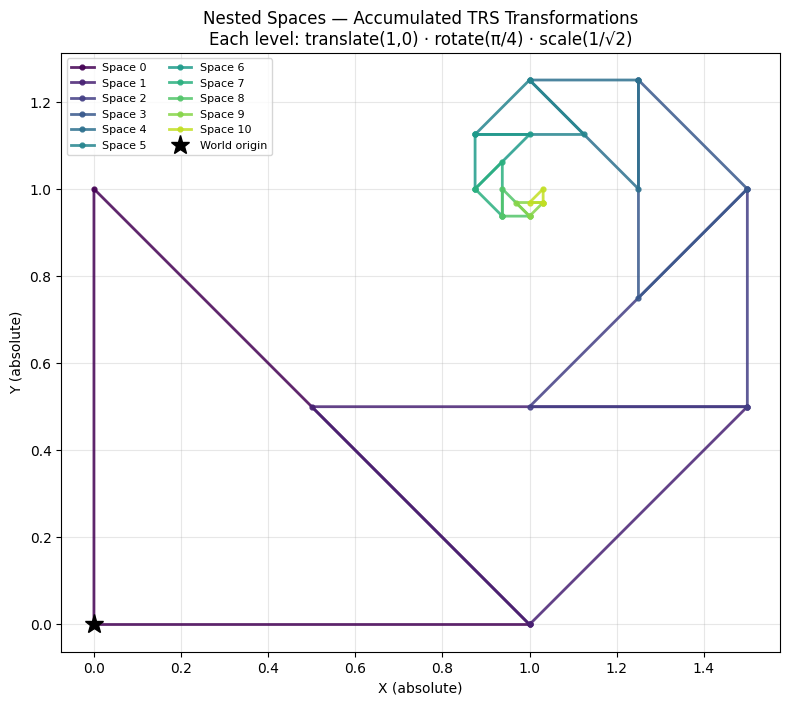

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from coordinatus import Space2D, Point, create_space

# Root world space
root = Space2D()

# Build 10 nested child spaces, each with the same TRS
spaces = [root]
for _ in range(10):
    spaces.append(
        create_space(
            parent=spaces[-1],
            tx=1,
            ty=0,
            angle_rad=np.pi / 4,
            sx=1 / 2**0.5,
            sy=1 / 2**0.5,
        )
    )

# Local triangle corners (same in every space)
local_triangle = [(0, 0), (1, 0), (0, 1)]

fig, ax = plt.subplots(figsize=(8, 8))
cmap = mpl_cm.get_cmap("viridis")

for idx, space in enumerate(spaces):
    color = cmap(idx / len(spaces))
    abs_pts = [
        Point(np.array([x, y]), space=space).to_absolute().coords
        for x, y in local_triangle
    ]
    xs = [p[0] for p in abs_pts] + [abs_pts[0][0]]
    ys = [p[1] for p in abs_pts] + [abs_pts[0][1]]
    ax.plot(xs, ys, ".-", color=color, linewidth=2, markersize=7,
            label=f"Space {idx}", alpha=0.85)

ax.plot(0, 0, "k*", markersize=14, zorder=10, label="World origin")
ax.set_aspect("equal")
ax.set_xlabel("X (absolute)")
ax.set_ylabel("Y (absolute)")
ax.set_title(
    "Nested Spaces — Accumulated TRS Transformations\n"
    "Each level: translate(1,0) · rotate(π/4) · scale(1/√2)"
)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Key observations

- **Accumulated rotation**: each space is 45° further around.
- **Accumulated scale**: each space is ×(1/√2) smaller than its parent.
- **The spiral**: because the scale precisely compensates the distance added
  by the unit translation, origins converge toward a fixed point.
- **The triangle shrinks**: it gets smaller at every level because scale
  affects the local axes, not just the origin.
